# Weather Copernicus–TAHMO Regression Notebook

**Data sources read by this notebook:**

- TAHMO combined shapefile: `../files/miscellaneous/Hourly GDFs/Combined_Hourly.shp`
- TAHMO hourly timestamp list: `../files/miscellaneous/Hourly GDFs/Hourly_Df_Hour_List.txt`
- Copernicus combined shapefile: `../files/miscellaneous/Hourly GDFs/Combined_Hourly_Copernicus_Data.shp`
- Copernicus hourly timestamp list: `../files/miscellaneous/Hourly GDFs/Copernicus_Hourly_Df_Hour_List.txt`

These paths are relative to the `notebooks` folder in the cluster project structure.

In [1]:
# Imports
from pathlib import Path
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point, Polygon
from datetime import datetime
from scipy.stats import linregress

project_root = Path.cwd().resolve()

# Allow execution from either the project root or notebooks folder
if project_root.name == "notebooks":
    project_root = project_root.parent
elif (
    not (project_root / "files").exists()
    and (project_root.parent / "files").exists()
):
    project_root = project_root.parent

# Cluster data location
hourly_dir = project_root / "files" / "miscellaneous" / "Hourly GDFs"

tahmo_path = hourly_dir / "Combined_Hourly.shp"
copernicus_path = hourly_dir / "Combined_Hourly_Copernicus_Data.shp"

# Confirm that the main input files exist
for path in [tahmo_path, copernicus_path]:
    if not path.exists():
        raise FileNotFoundError(f"Required input not found: {path}")

print(f"Project root: {project_root}")
print(f"Hourly data directory: {hourly_dir}")

Project root: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1
Hourly data directory: /work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__Cleaned_Up_Project_1/files/miscellaneous/Hourly GDFs


In [18]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

In [2]:
# Read TAHMO combined hourly shapefile and fix truncated column names
tahmo_combined_hourly = gpd.read_file(tahmo_path)
tahmo_combined_hourly = tahmo_combined_hourly.rename(columns={'Precipitat': 'Precip_Tahmo', 'Temperatur': 'Temp_Tahmo'})

In [3]:
# Read the TAHMO timestamp list and attach as 'Timestamp' column
with open(hourly_dir / 'Hourly_Df_Hour_List.txt', 'r') as file:
    my_list = [datetime.strptime(line.strip(), '%Y-%m-%d %H:%M:%S') for line in file.readlines()]
formatted_list = [dt.strftime('%Y-%m-%d %H:%M:%S') for dt in my_list]
tahmo_combined_hourly['Timestamp'] = formatted_list
tahmo_combined_hourly['Timestamp'] = pd.to_datetime(tahmo_combined_hourly['Timestamp'])

In [4]:
# Subset TAHMO by year (example years used in original notebook)
tahmo_2020 = tahmo_combined_hourly[tahmo_combined_hourly['Timestamp'].dt.year == 2020]
tahmo_2021 = tahmo_combined_hourly[tahmo_combined_hourly['Timestamp'].dt.year == 2021]
tahmo_2022 = tahmo_combined_hourly[tahmo_combined_hourly['Timestamp'].dt.year == 2022]

In [5]:
# Read Copernicus combined hourly shapefile and fix column names
copernicus_hourly = gpd.read_file(copernicus_path)
copernicus_hourly = copernicus_hourly.rename(columns={'valid_time': 'Timestamp', 'Location_I': 'Location_ID', 'Precip (mm': 'Precip_Coper', 'Temp (C)':'Temp_Coper'})

In [6]:
# Read Copernicus timestamp list and attach as 'Timestamp' column
with open(hourly_dir / 'Copernicus_Hourly_Df_Hour_List.txt', 'r') as file:
    my_list_2 = [datetime.strptime(line.strip(), '%Y-%m-%d %H:%M:%S') for line in file.readlines()]
formatted_list_2 = [dt.strftime('%Y-%m-%d %H:%M:%S') for dt in my_list_2]
copernicus_hourly['Timestamp'] = formatted_list_2
copernicus_hourly['Timestamp'] = pd.to_datetime(copernicus_hourly['Timestamp'])

In [7]:
# Subset Copernicus by year
copernicus_2020 = copernicus_hourly[copernicus_hourly['Timestamp'].dt.year == 2020]
copernicus_2021 = copernicus_hourly[copernicus_hourly['Timestamp'].dt.year == 2021]
copernicus_2022 = copernicus_hourly[copernicus_hourly['Timestamp'].dt.year == 2022]

In [8]:
# Utility: keep one instance per value in a column
def filter_keep_one_instance(df, column_name):
    mask = ~df[column_name].duplicated(keep='first')
    return df[mask]

In [9]:
# Filter to representative rows for mapping between datasets
filtered_tahmo_df = filter_keep_one_instance(tahmo_2022, 'Site_Name')
filtered_coper_df = filter_keep_one_instance(copernicus_2022, 'Location_ID')

In [10]:
# Find nearby TAHMO stations for each Copernicus point (buffer in meters)
def count_nearby_locations_with_names(tahmo_gdf, copernicus_gdf, distance_meters):
    # Project once and work on copies to avoid SettingWithCopyWarning
    tahmo_gdf_projected = tahmo_gdf.to_crs(epsg=32630)
    copernicus_proj = copernicus_gdf.to_crs(epsg=32630).copy()
    buffers = copernicus_proj.geometry.buffer(distance_meters)
    tahmo_counts = []
    tahmo_names = []
    for buf in buffers:
        nearby_locations = tahmo_gdf_projected[tahmo_gdf_projected.geometry.within(buf)]
        tahmo_counts.append(int(nearby_locations.shape[0]))
        tahmo_names.append(', '.join(nearby_locations['Site_Name'].astype(str).tolist()))
    # Return a safe copy of the original GeoDataFrame with new columns set via .loc
    result = copernicus_gdf.copy().reset_index(drop=True)
    result.loc[:, 'tahmo_count'] = tahmo_counts
    result.loc[:, 'tahmo_names'] = tahmo_names
    return result



### Define distance threshold for nearby TAHMO stations (in meters)
## 6km 
buffer_df = count_nearby_locations_with_names(filtered_tahmo_df, filtered_coper_df, 6000)

In [11]:
# Create dictionary mapping Location_ID -> tahmo site names and filter non-empty entries
site_mapping = buffer_df.set_index('Location_ID')['tahmo_names'].to_dict()
filtered_site_dict = {k: v for k, v in site_mapping.items() if v != ''}

In [12]:
# Filter dataframes helper (temperature)
def filter_dataframes(copernicus_df, tahmo_df, filter_dict):
    copernicus_df = copernicus_df[copernicus_df['Location_ID'].apply(lambda x: bool(filter_dict.get(x, '').strip()))]
    valid_site_names = set(site_name.strip() for value in filter_dict.values() if value for site_name in value.split(','))
    tahmo_df = tahmo_df[tahmo_df['Site_Name'].isin(valid_site_names)]
    copernicus_df = copernicus_df[['Timestamp', 'Temp_Coper', 'Location_ID']].reset_index(drop=True)
    tahmo_df = tahmo_df[['Timestamp', 'Temp_Tahmo', 'Site_Name']].reset_index(drop=True)
    return copernicus_df, tahmo_df

filtered_copernicus, filtered_tahmo = filter_dataframes(copernicus_2022, tahmo_2022, filtered_site_dict)

In [13]:
# Average & merge helpers (temperature)
def average_and_merge_dfs(dfs, on_column, avg_column):
    if not dfs:
        raise ValueError('At least one DataFrame is required for averaging and merging.')
    if len(dfs) == 1:
        # avoid SettingWithCopyWarning by working on a copy and using .loc
        df0 = dfs[0].copy()
        df0.loc[:, f'Average_{avg_column}'] = df0[avg_column]
        return df0
    temp_dfs = []
    for i, df in enumerate(dfs):
        temp_dfs.append(
            df[[on_column, avg_column]].rename(columns={avg_column: f"{avg_column}_{i+1}"})
        )
    merged_temp_df = temp_dfs[0]
    for temp_df in temp_dfs[1:]:
        merged_temp_df = pd.merge(merged_temp_df, temp_df, on=on_column, how='inner')
    avg_columns = [col for col in merged_temp_df.columns if col.startswith(avg_column)]
    merged_temp_df[f'Average_{avg_column}'] = merged_temp_df[avg_columns].mean(axis=1)
    merged_temp_df = merged_temp_df[[on_column, f'Average_{avg_column}']]
    # merge into a copy of the first df to avoid SettingWithCopyWarning
    base = dfs[0].copy()
    final_merged_df = base.merge(merged_temp_df, on=on_column, how='inner')
    return final_merged_df

def average_and_merge_site_dfs_from_dict_with_copernicus(dfs, on_column, avg_column, site_dict, copernicus_df, copernicus_column):
    if not site_dict or len(site_dict) < 1:
        raise ValueError('The site_dict should contain at least one entry.')
    merged_results = []
    for location_id, site_list in site_dict.items():
        site_names = site_list.split(', ')
        filtered_dfs = [dfs[dfs['Site_Name'] == site_name] for site_name in site_names]
        merged_df = average_and_merge_dfs(filtered_dfs, on_column, avg_column)
        # operate on a copy to avoid SettingWithCopyWarning
        merged_df = merged_df.copy()
        merged_df.loc[:, 'Location_ID'] = location_id
        filtered_copernicus = copernicus_df[copernicus_df['Location_ID'] == location_id]
        if len(filtered_copernicus) == len(merged_df):
            merged_df.loc[:, 'Temp_Copernicus'] = filtered_copernicus[copernicus_column].values
        else:
            raise ValueError(f'Row mismatch between Copernicus data and merged DataFrame for Location_ID {location_id}')
        merged_results.append(merged_df)
    final_merged_df = pd.concat(merged_results, ignore_index=True)
    return final_merged_df

def process_year_data(tahmo_df, copernicus_df, dict):
    filtered_copernicus, filtered_tahmo = filter_dataframes(copernicus_df, tahmo_df, dict)
    result_df = average_and_merge_site_dfs_from_dict_with_copernicus(
        dfs=filtered_tahmo,
        on_column='Timestamp',
        avg_column='Temp_Tahmo',
        site_dict = dict,
        copernicus_df=filtered_copernicus,
        copernicus_column='Temp_Coper'
    )
    return result_df




# Process years (this will run the pipeline for temperature)
# result = process_year_data(tahmo_2020, copernicus_2020, filtered_site_dict)
# result = process_year_data(tahmo_2021, copernicus_2021, filtered_site_dict)
result = process_year_data(tahmo_2022, copernicus_2022, filtered_site_dict)

In [21]:
def plot_linear_fit(
    df,
    x_col,
    y_col,
    x_label=None,
    y_label=None,
    title=None,

    # Figure
    figsize=(8, 6),
    dpi=300,
    save_path=None,

    # Panel label
    panel_label='b',
    panel_label_x=-0.01,
    panel_label_y=1.05,
    panel_label_fontsize=14,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='top',

    # Axis limits and scaling
    axis_limits=None,
    equal_aspect=True,

    # Scatter points
    point_label='Data points',
    point_color='blue',
    point_alpha=0.30,
    point_size=20,

    # Fitted regression line
    fit_color='red',
    fit_linewidth=2,
    fit_linestyle='-',

    # Axis labels
    x_label_fontsize=14,
    y_label_fontsize=14,
    x_label_fontweight='bold',
    y_label_fontweight='bold',
    x_labelpad=10,
    y_labelpad=10,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,

    # Grid
    show_grid=True,
    grid_alpha=0.20,
    grid_color='grey',
    grid_linestyle='-',
    grid_linewidth=0.8,

    # Legend
    show_legend=True,
    legend_fontsize=12,
    legend_loc='upper left',
    legend_bbox=None,

    # Spines
    hide_top_spine=True,
    hide_right_spine=True,
):
    """
    Plot two variables and their fitted linear regression line.

    Parameters
    ----------
    axis_limits : tuple or None
        Common limits applied to both axes, e.g. (15, 38).

    equal_aspect : bool
        If True, one unit occupies the same physical distance on both axes.
    """

    # Keep complete x-y pairs without modifying the original DataFrame
    plot_df = (
        df[[x_col, y_col]]
        .dropna()
        .sort_values(x_col)
        .copy()
    )

    if len(plot_df) < 2:
        raise ValueError(
            'At least two complete observations are required.'
        )

    x = plot_df[x_col]
    y = plot_df[y_col]

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    fitted_values = slope * x + intercept
    r_squared = r_value**2

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

        # Panel label positioned relative to the axes
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            panel_label,
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            ha=panel_label_ha,
            va=panel_label_va
        )

    # Scatter points
    ax.scatter(
        x,
        y,
        label=point_label,
        color=point_color,
        alpha=point_alpha,
        s=point_size
    )

    # Fitted regression line
    ax.plot(
        x,
        fitted_values,
        label=(
            fr'Linear fit ($R$ = {r_value:.2f}, '
            fr'$R^2$ = {r_squared:.2f})'
        ),
        color=fit_color,
        linewidth=fit_linewidth,
        linestyle=fit_linestyle
    )

    # Axis labels
    ax.set_xlabel(
        x_label or x_col,
        fontsize=x_label_fontsize,
        fontweight=x_label_fontweight,
        labelpad=x_labelpad
    )

    ax.set_ylabel(
        y_label or y_col,
        fontsize=y_label_fontsize,
        fontweight=y_label_fontweight,
        labelpad=y_labelpad
    )

    # Title
    if title:
        ax.set_title(title)

    # Common limits for both axes
    if axis_limits is not None:
        ax.set_xlim(axis_limits)
        ax.set_ylim(axis_limits)

    # Same physical scaling for x and y
    if equal_aspect:
        ax.set_aspect('equal', adjustable='box')

    # Tick labels
    ax.tick_params(
        axis='x',
        labelsize=x_tick_fontsize
    )
    ax.tick_params(
        axis='y',
        labelsize=y_tick_fontsize
    )

    # Gridlines
    if show_grid:
        ax.grid(
            True,
            color=grid_color,
            alpha=grid_alpha,
            linestyle=grid_linestyle,
            linewidth=grid_linewidth
        )

    # Hide upper and right spines
    if hide_top_spine:
        ax.spines['top'].set_visible(False)

    if hide_right_spine:
        ax.spines['right'].set_visible(False)

    # Legend
    if show_legend:
        legend_kwargs = {
            'fontsize': legend_fontsize,
            'loc': legend_loc
        }

        if legend_bbox is not None:
            legend_kwargs['bbox_to_anchor'] = legend_bbox

        ax.legend(**legend_kwargs)

    plt.tight_layout()

    if save_path is not None:

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    # print(f'R = {r_value:.3f}')
    # print(f'R² = {r_squared:.3f}')
    # print(f'p-value = {p_value:.3e}')

    return slope, intercept, r_value, p_value, std_err

In [15]:
# if not result.empty:
#     slope, intercept, r_value, p_value, std_err = plot_linear_fit(
#         df=result,
#         x_col='Average_Temp_Tahmo',
#         y_col='Temp_Copernicus',

#         x_label='Temperature — Weather Stations (°C)',
#         y_label='Temperature — Copernicus (°C)',
#         title=None,

#         figsize=(8, 8),
#         dpi=300,
#         # save_path= 'tahmo_copernicus_temp_comparison.png',

#         # Panel label
#         panel_label='z',
#         panel_label_x=-0.01,
#         panel_label_y=1.05,
#         panel_label_fontsize=14,
#         panel_label_fontweight='bold',
#         panel_label_ha='left',
#         panel_label_va='top',

#         # Same numerical limits and physical scale
#         axis_limits=(16, 38),
#         equal_aspect=True,

#         # Scatter points
#         point_color='blue',
#         point_alpha=0.30,
#         point_size=18,

#         # Regression line
#         fit_color='red',
#         fit_linewidth=2,
#         fit_linestyle='-',

#         # Axis labels
#         x_label_fontsize=14,
#         y_label_fontsize=14,
#         x_labelpad=12,
#         y_labelpad=12,

#         # Tick labels
#         x_tick_fontsize=12,
#         y_tick_fontsize=12,

#         # Gridlines
#         show_grid=True,
#         grid_alpha=0.20,
#         grid_color='grey',

#         # Legend
#         legend_fontsize=12,
#         legend_loc='upper left',

#         # Spines
#         hide_top_spine=True,
#         hide_right_spine=True
#     )

In [16]:
# --- Precipitation pipeline helpers (cleaned) ---
def filter_dataframes_PRECIP(copernicus_df, tahmo_df, filter_dict):
    copernicus_df = copernicus_df[copernicus_df['Location_ID'].apply(lambda x: bool(filter_dict.get(x, '').strip()))]
    valid_site_names = set(site_name.strip() for value in filter_dict.values() if value for site_name in value.split(','))
    tahmo_df = tahmo_df[tahmo_df['Site_Name'].isin(valid_site_names)]
    copernicus_df = copernicus_df[['Timestamp', 'Precip_Coper', 'Location_ID']].reset_index(drop=True)
    tahmo_df = tahmo_df[['Timestamp', 'Precip_Tahmo', 'Site_Name']].reset_index(drop=True)
    return copernicus_df, tahmo_df

def average_and_merge_dfs_PRECIP(dfs, on_column, avg_column):
    if not dfs:
        raise ValueError('At least one DataFrame is required for averaging and merging.')
    if len(dfs) == 1:
        # avoid SettingWithCopyWarning by using a copy and .loc
        df0 = dfs[0].copy()
        df0.loc[:, f'Average_{avg_column}'] = df0[avg_column]
        return df0
    precip_dfs = []
    for i, df in enumerate(dfs):
        precip_dfs.append(
            df[[on_column, avg_column]].rename(columns={avg_column: f"{avg_column}_{i+1}"})
        )
    merged_precip_df = precip_dfs[0]
    for precip_df in precip_dfs[1:]:
        merged_precip_df = pd.merge(merged_precip_df, precip_df, on=on_column, how='inner')
    avg_columns = [col for col in merged_precip_df.columns if col.startswith(avg_column)]
    merged_precip_df[f'Average_{avg_column}'] = merged_precip_df[avg_columns].mean(axis=1)
    merged_precip_df = merged_precip_df[[on_column, f'Average_{avg_column}']]
    base = dfs[0].copy()
    final_merged_df = base.merge(merged_precip_df, on=on_column, how='inner')
    return final_merged_df

def average_and_merge_site_dfs_from_dict_with_copernicus_PRECIP(dfs, on_column, avg_column, site_dict, copernicus_df, copernicus_column):
    if not site_dict or len(site_dict) < 1:
        raise ValueError('The site_dict should contain at least one entry.')
    merged_results = []
    for location_id, site_list in site_dict.items():
        site_names = site_list.split(', ')
        filtered_dfs = [dfs[dfs['Site_Name'] == site_name] for site_name in site_names]
        merged_df = average_and_merge_dfs_PRECIP(filtered_dfs, on_column, avg_column)
        # avoid SettingWithCopyWarning
        merged_df = merged_df.copy()
        merged_df.loc[:, 'Location_ID'] = location_id
        filtered_copernicus = copernicus_df[copernicus_df['Location_ID'] == location_id]
        if len(filtered_copernicus) == len(merged_df):
            merged_df.loc[:, 'Precip_Copernicus'] = filtered_copernicus[copernicus_column].values
        else:
            raise ValueError(f'Row mismatch between Copernicus data and merged DataFrame for Location_ID {location_id}')
        merged_results.append(merged_df)
    final_merged_df = pd.concat(merged_results, ignore_index=True)
    return final_merged_df

def process_year_data_PRECIP(tahmo_df, copernicus_df, dict):
    filtered_copernicus, filtered_tahmo = filter_dataframes_PRECIP(copernicus_df, tahmo_df, dict)
    result_df_PRECIP = average_and_merge_site_dfs_from_dict_with_copernicus_PRECIP(
        dfs=filtered_tahmo,
        on_column='Timestamp',
        avg_column='Precip_Tahmo',
        site_dict = dict,
        copernicus_df=filtered_copernicus,
        copernicus_column='Precip_Coper'
    )
    return result_df_PRECIP

# Run precipitation pipeline (will compute result_PRECIP)
result_PRECIP = process_year_data_PRECIP(tahmo_2022, copernicus_2022, filtered_site_dict)

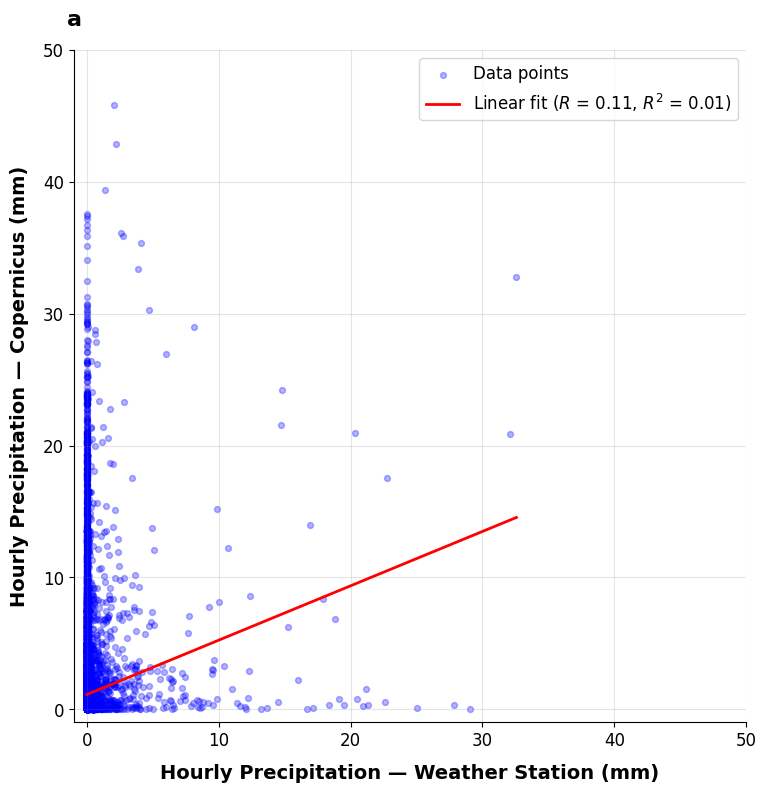

In [24]:
if not result_PRECIP.empty:
    slope, intercept, r_value, p_value, std_err = plot_linear_fit(
        df=result_PRECIP,
        x_col='Average_Precip_Tahmo',
        y_col='Precip_Copernicus',

        x_label='Hourly Precipitation — Weather Station (mm)',
        y_label='Hourly Precipitation — Copernicus (mm)',
        title=None,

        figsize=(8, 8),
        dpi=100,
        # save_path= 'tahmo_copernicus_precip_comparison.png',

        # Same numerical limits and physical scale
        axis_limits=(-1, 50),
        equal_aspect=True,        

        # Scatter points
        point_color='blue',
        point_alpha=0.30,
        point_size=18,

        # Regression line
        fit_color='red',
        fit_linewidth=2,
        fit_linestyle='-',

        # Axis labels
        x_label_fontsize=14,
        y_label_fontsize=14,
        x_labelpad=10,
        y_labelpad=10,

        panel_label='a',
        panel_label_x=-0.01,
        panel_label_y=1.06,
        panel_label_fontsize=16,

        # Tick labels
        x_tick_fontsize=12,
        y_tick_fontsize=12,

        # Gridlines
        show_grid=True,
        grid_alpha=0.20,
        grid_color='grey',

        # Legend
        legend_fontsize=12,
        legend_loc='upper right',

        # Spines
        hide_top_spine=True,
        hide_right_spine=True, 

        save_path = (PLOTS_DIR/ 'Copernicus_regression.png')
    )